# Automatic identification of order parameters for symmetry broken states

`scf.identify_symmetry_breaking()` compares the converged mean-field Hamiltonian against the bare
one and projects their difference onto a library of known symmetry-breaking patterns (Neel, ferro,
Haldane mass, charge density wave, singlet/triplet pairing, ...), returning a human-readable label
without the user having to guess what order emerged. `scf.order_parameter(name)` extracts the actual
complex order-parameter amplitude for the `"even_SC"`/`"odd_SC"` (singlet/triplet pairing) channels.

V2-driven instability identified as: ['Haldane']


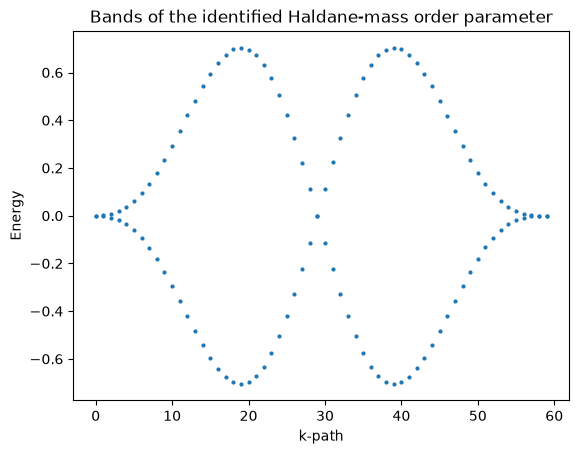

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import meanfield

# a spontaneous Haldane mass from a second-neighbor density-density interaction
g = geometry.honeycomb_lattice()
h = g.get_hamiltonian(has_spin=False)
mf = meanfield.guess(h,"random")
scf = meanfield.Vinteraction(h,mf=mf,V2=2.0,nk=6,filling=0.5,mix=0.1)
print("V2-driven instability identified as:",scf.identify_symmetry_breaking())

hcorr = h - scf.hamiltonian # the mean-field correction alone
(k,e) = hcorr.get_bands(nk=60)

plt.scatter(k,e,s=4)
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Bands of the identified Haldane-mass order parameter")
plt.show()

A Haldane mass turns the interacting ground state into a Chern insulator without any external
magnetic field. The Berry curvature of the self-consistent mean-field Hamiltonian over reciprocal
space shows it: it is peaked at the K and K' points with the same sign in both valleys, and it
integrates to a Chern number of $\pm 1$, the sign being picked by the random initial guess.

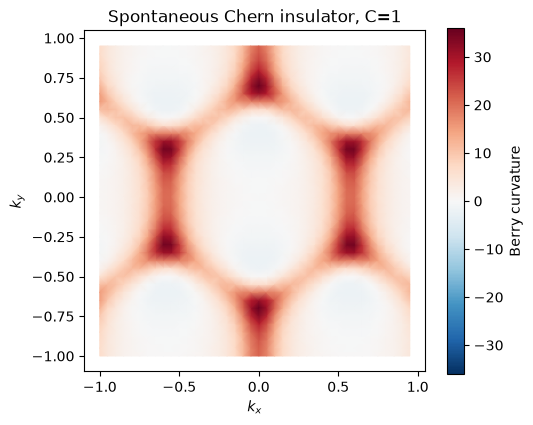

In [2]:
(kx,ky,b) = scf.hamiltonian.get_berry_curvature(nk=40,write=False) # Berry curvature map
C = scf.hamiltonian.get_chern(nk=20) # its integral over the Brillouin zone

bmax = np.max(np.abs(b)) # symmetric color scale
plt.figure(figsize=(5.5,4.5))
plt.tripcolor(kx,ky,b,cmap="RdBu_r",shading="gouraud",vmin=-bmax,vmax=bmax)
plt.colorbar(label="Berry curvature")
plt.gca().set_aspect("equal")
plt.xlabel("$k_x$") ; plt.ylabel("$k_y$")
plt.title(f"Spontaneous Chern insulator, C={C:.0f}")
plt.show()